<a href="https://www.kaggle.com/code/sonawanelalitsunil/medical-insurance-cost-ml-87?scriptVersionId=260963748" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/medical-insurance-cost-dataset/insurance.csv


## Title:
Medical Insurance Cost Dataset

## Description:
This dataset contains information about individuals’ demographic, lifestyle, and health-related factors, along with their corresponding medical insurance costs. It is commonly used to analyze the relationship between personal attributes and insurance charges. The dataset includes variables such as age, gender, BMI, number of children, smoking habits, and region of residence, which influence the cost of medical insurance. It can be applied for regression modeling, cost prediction, risk analysis, and understanding healthcare expenditure trends.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/medical-insurance-cost-dataset/insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [6]:
df.shape

(1338, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.duplicated().sum()

1

In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## Data visualizations

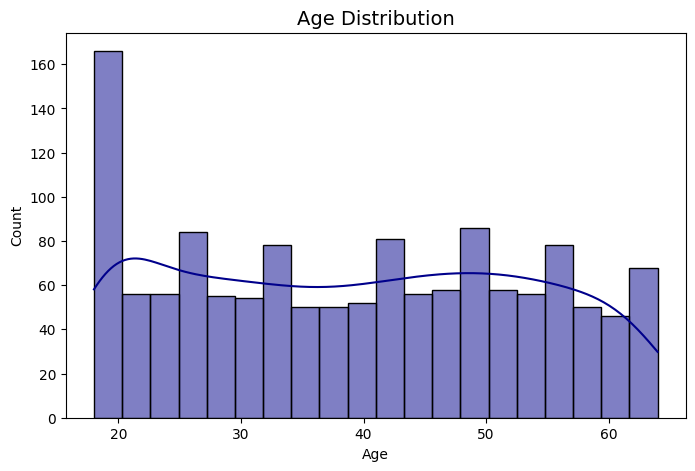

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color="darkblue")
plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


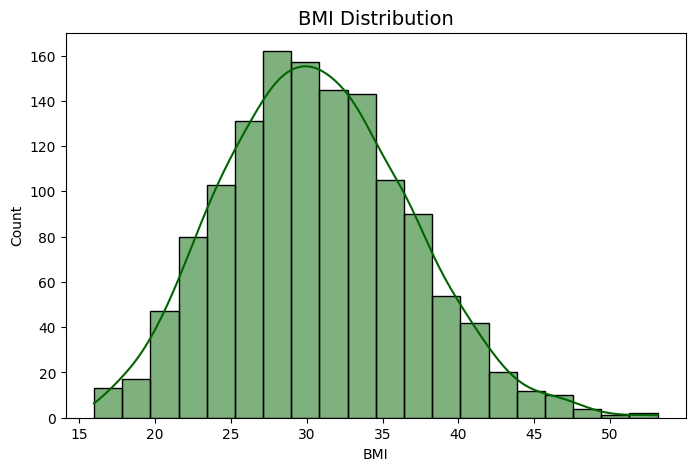

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=20, kde=True, color="darkgreen")
plt.title("BMI Distribution", fontsize=14)
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

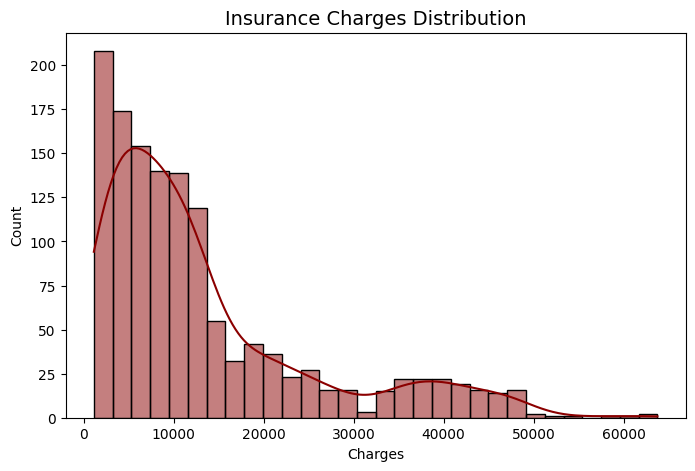

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True, color="darkred")
plt.title("Insurance Charges Distribution", fontsize=14)
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

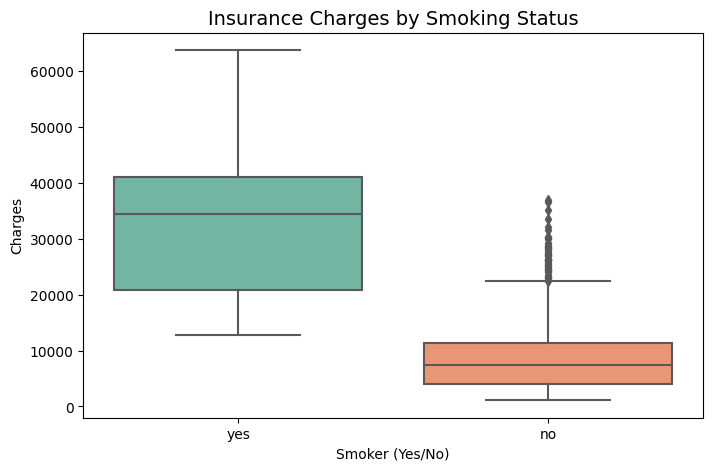

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x="smoker", y="charges", data=df, palette="Set2")
plt.title("Insurance Charges by Smoking Status", fontsize=14)
plt.xlabel("Smoker (Yes/No)")
plt.ylabel("Charges")
plt.show()


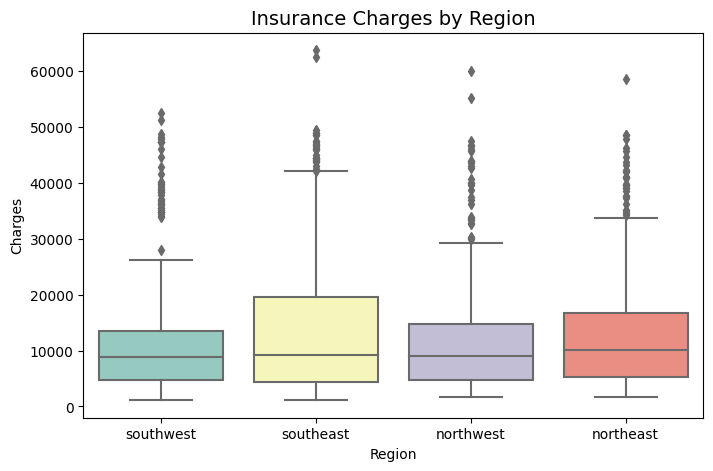

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="region", y="charges", data=df, palette="Set3")
plt.title("Insurance Charges by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

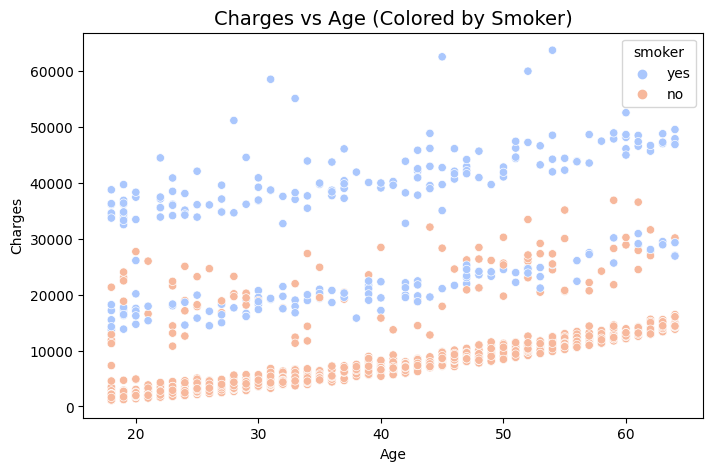

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df, palette="coolwarm")
plt.title("Charges vs Age (Colored by Smoker)", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

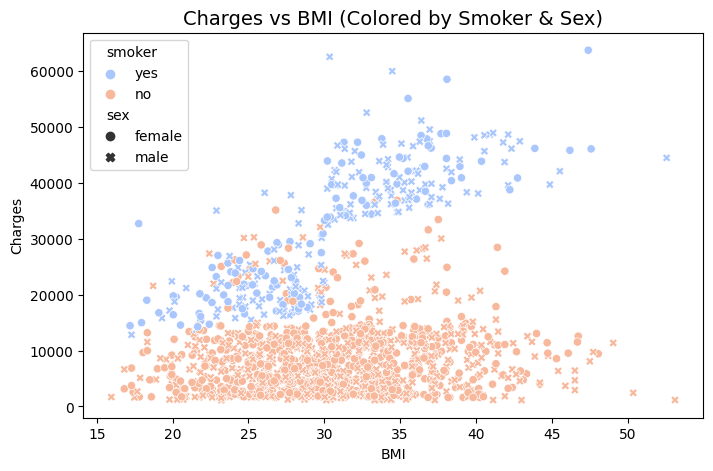

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="charges", hue="smoker", style="sex", data=df, palette="coolwarm")
plt.title("Charges vs BMI (Colored by Smoker & Sex)", fontsize=14)
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

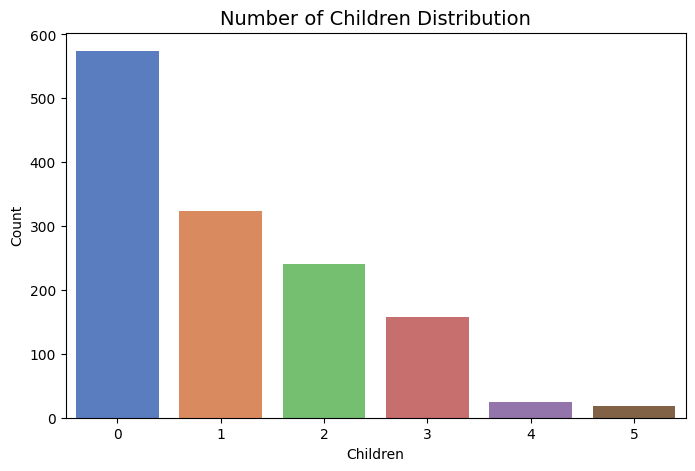

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x="children", data=df, palette="muted")
plt.title("Number of Children Distribution", fontsize=14)
plt.xlabel("Children")
plt.ylabel("Count")
plt.show()

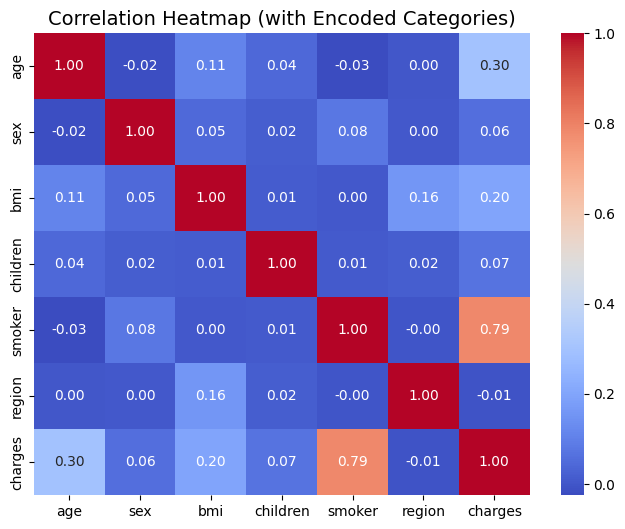

In [20]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
encoded_df = df.copy()
for col in ['sex', 'smoker', 'region']:
    encoded_df[col] = LabelEncoder().fit_transform(encoded_df[col])

# Heatmap with encoded categorical + numeric
plt.figure(figsize=(8,6))
sns.heatmap(encoded_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (with Encoded Categories)", fontsize=14)
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [22]:
# Label Encoding categorical columns
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop("charges", axis=1)
y = df["charges"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

In [24]:
# Train & Evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred) * 100   # R² score as accuracy %
    results[name] = score
    print(f"{name:25} : {score:.2f} %")

Linear Regression         : 78.33 %
Random Forest             : 86.43 %
Gradient Boosting         : 87.80 %
Support Vector Regressor  : -7.23 %
XGBoost                   : 85.02 %


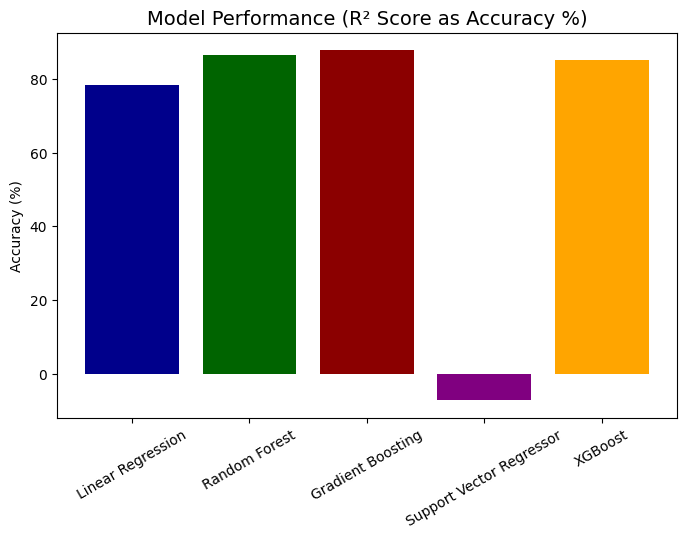

In [25]:
# Bar Chart of Results
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=["darkblue","darkgreen","darkred","purple","orange"])
plt.title("Model Performance (R² Score as Accuracy %)", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.show()

## Thank you..pls upvote!!!